# Variational Quantum Algorithm (VQA) Workflow

This notebook demonstrates the fundamental workflow of a Variational Quantum Algorithm.
The typical workflow consists of four main steps:
1. Define the cost function (represented as an observable/Hamiltonian).
2. Prepare the parameterized quantum circuit (Ansatz).
3. Evaluate the cost function using a quantum backend (via EstimatorV2).
4. Optimize the parameters using a classical optimizer.

In [1]:
import numpy as np
from scipy.optimize import minimize
from qiskit.circuit.library import RealAmplitudes
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator

## Step 1: Define the Hamiltonian (Observable)
We use a simple observable: Z on qubit 0, Z on qubit 1, and an XX interaction.

In [2]:
observable = SparsePauliOp(["ZZ", "XX", "IZ"], coeffs=[1.0, 0.5, -0.2])
print("Target Observable:")
print(observable)

Target Observable:
SparsePauliOp(['ZZ', 'XX', 'IZ'],
              coeffs=[ 1. +0.j,  0.5+0.j, -0.2+0.j])


## Step 2: Prepare the Parameterized Quantum Circuit (Ansatz)
We use a hardware efficient ansatz, `RealAmplitudes`, which consists of Ry rotations and CX entanglements.

Number of parameters to optimize: 4


/tmp/ipykernel_115984/2344182194.py:1: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=2, reps=1)


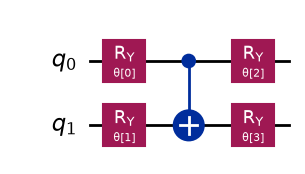

In [3]:
ansatz = RealAmplitudes(num_qubits=2, reps=1)
num_params = ansatz.num_parameters
print(f"Number of parameters to optimize: {num_params}")
ansatz.decompose().draw('mpl')

## Step 3 & 4: Evaluate and Optimize
For this playground, we will use the local `StatevectorEstimator` to evaluate the expectation values.

In [4]:
estimator = StatevectorEstimator()
history = {"cost": [], "params": []}

def cost_function(params):
    # The new EstimatorV2 interface expects a pub (primitive unified builder) tuple
    pub = (ansatz, observable, params)
    job = estimator.run([pub])
    result = job.result()[0]
    
    expectation_value = result.data.evs
    history["cost"].append(expectation_value)
    history["params"].append(params)
    
    return expectation_value

# Initial guess
initial_params = np.random.uniform(0, 2 * np.pi, num_params)
print(f"Initial Cost: {cost_function(initial_params):.4f}")

Initial Cost: -0.4156


Now we run the classical optimization using COBYLA.

In [5]:
result = minimize(
    cost_function,
    initial_params,
    method="COBYLA",
    options={"maxiter": 100, "tol": 1e-3}
)

print(f"Success: {result.success}")
print(f"Number of iterations: {result.nfev}")
print(f"Minimum Eigenvalue Found: {result.fun:.4f}")
print(f"Optimal Parameters: {result.x}")

Success: True
Number of iterations: 70
Minimum Eigenvalue Found: -1.5385
Optimal Parameters: [4.49937285 2.82256369 2.17350215 2.13860361]
